In [20]:
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
import copy
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Data_path="/content/drive/MyDrive/DSC4213/2_programming assignment/Data_A2"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Configuration and Data Augmentation

In [13]:
batch_size=16
img_size= (224,224)

# Data augmentation for training
train_transform= transforms.Compose([
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# No augmentation for validation
val_transform= transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(Data_path, transform=train_transform)
val_dataset = datasets.ImageFolder(Data_path, transform=val_transform)

labels = train_dataset.targets

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in sss.split(range(len(train_dataset)), labels):
    train_set = Subset(train_dataset, train_idx)
    val_set   = Subset(val_dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=16)

print("Classes:", train_dataset.classes)
print("Total images:", len(train_dataset))

Classes: ['algal leaf', 'brown blight', 'white spot']
Total images: 368


Model Building

In [14]:
vgg = models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)

for param in vgg.features.parameters():
    param.requires_grad = False

for param in vgg.features[24:].parameters():
    param.requires_grad = True
vgg.classifier[6] = nn.Linear(4096, 3)
vgg = vgg.to(device)

resnet = models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)

for name, param in resnet.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features, 3)
resnet = resnet.to(device)
print("ResNet50 ready")

ResNet50 ready


Training Loop Function

In [15]:
def train_model(model, model_name, epochs=10, save_dir="/content/drive/MyDrive/DSC4213/2_programming assignment/Data_A2/"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5
    )

    train_losses, train_accs, val_accs = [], [], []

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        train_correct = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            total_train += labels.size(0)

        model.eval()
        correct = 0
        val_running_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_running_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()

        train_acc = train_correct / total_train
        val_acc = correct / len(val_set)
        epoch_loss = running_loss / len(train_loader)
        val_loss = val_running_loss / len(val_loader)

        train_losses.append(epoch_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']


        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, f"{save_dir}{model_name}_best.pth")
            print(f"   -> New best model saved (Val Acc = {best_val_acc:.4f})")

    print(f"Best validation accuracy: {best_val_acc:.4f}")
    model.load_state_dict(best_model_wts)

    return train_losses, train_accs, val_accs

print("Training VGG16...")
vgg_losses, vgg_train_accs, vgg_accs = train_model(vgg, "VGG16")

print("\nTraining ResNet50...")
resnet_losses, resnet_train_accs, resnet_accs = train_model(resnet, "ResNet50")

Training VGG16...
[VGG16] Epoch 1/10 | Loss: 1.0589 | Train Acc: 0.4524 | Val Acc: 0.6081 | LR: 0.000100
   -> New best model saved (Val Acc = 0.6081)
[VGG16] Epoch 2/10 | Loss: 0.7601 | Train Acc: 0.6633 | Val Acc: 0.6351 | LR: 0.000100
   -> New best model saved (Val Acc = 0.6351)
[VGG16] Epoch 3/10 | Loss: 0.5862 | Train Acc: 0.7415 | Val Acc: 0.9054 | LR: 0.000100
   -> New best model saved (Val Acc = 0.9054)
[VGG16] Epoch 4/10 | Loss: 0.3549 | Train Acc: 0.8639 | Val Acc: 0.8514 | LR: 0.000100
[VGG16] Epoch 5/10 | Loss: 0.3555 | Train Acc: 0.8435 | Val Acc: 0.9054 | LR: 0.000100
[VGG16] Epoch 6/10 | Loss: 0.2636 | Train Acc: 0.8878 | Val Acc: 0.8919 | LR: 0.000100
[VGG16] Epoch 7/10 | Loss: 0.1359 | Train Acc: 0.9558 | Val Acc: 0.8378 | LR: 0.000100
[VGG16] Epoch 8/10 | Loss: 0.1466 | Train Acc: 0.9422 | Val Acc: 0.7838 | LR: 0.000100
[VGG16] Epoch 9/10 | Loss: 0.1870 | Train Acc: 0.9320 | Val Acc: 0.9459 | LR: 0.000100
   -> New best model saved (Val Acc = 0.9459)
[VGG16] Epoch 1

Classification Report

In [18]:
def evaluate_model(model, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n--- {model_name} Classification Report ---")
    print(classification_report(all_labels, all_preds,
          target_names=['algal leaf', 'brown blight', 'white spot']))

evaluate_model(vgg, "VGG16")
evaluate_model(resnet, "ResNet50")


--- VGG16 Classification Report ---
              precision    recall  f1-score   support

  algal leaf       1.00      1.00      1.00        23
brown blight       0.96      0.96      0.96        23
  white spot       0.96      0.96      0.96        28

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74


--- ResNet50 Classification Report ---
              precision    recall  f1-score   support

  algal leaf       0.92      1.00      0.96        23
brown blight       0.95      0.87      0.91        23
  white spot       0.96      0.96      0.96        28

    accuracy                           0.95        74
   macro avg       0.95      0.94      0.94        74
weighted avg       0.95      0.95      0.95        74



Visualizing the Model Performance

Confusion Matrix


--- Generating VGG16 Confusion Matrix ---


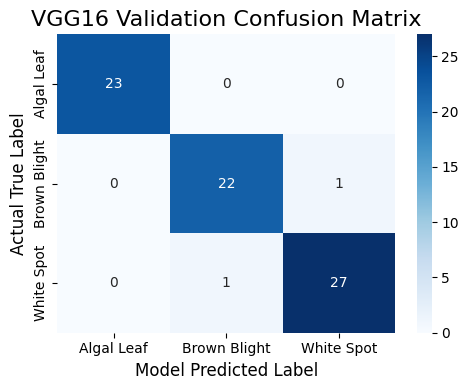


--- Generating ResNet50 Confusion Matrix ---


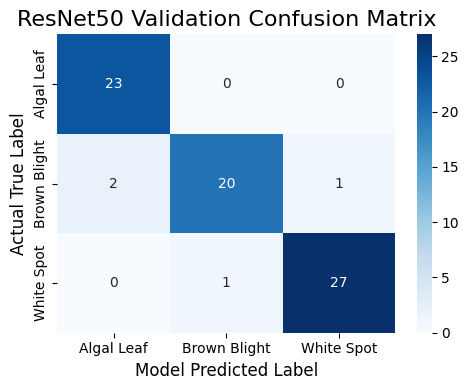

In [23]:
def plot_confusion_matrix(model, data_loader, class_names, title="Confusion Matrix"):
    """
    Evaluates the model on the provided data loader and plots a confusion matrix.
    """
    model.eval()
    all_preds = []
    all_labels = []


    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title(title, fontsize=16)
    plt.ylabel('Actual True Label', fontsize=12)
    plt.xlabel('Model Predicted Label', fontsize=12)

    plt.tight_layout()
    plt.show()


class_names = ['Algal Leaf', 'Brown Blight', 'White Spot']

print("\n--- Generating VGG16 Confusion Matrix ---")
plot_confusion_matrix(vgg, val_loader, class_names, title="VGG16 Validation Confusion Matrix")

print("\n--- Generating ResNet50 Confusion Matrix ---")
plot_confusion_matrix(resnet, val_loader, class_names, title="ResNet50 Validation Confusion Matrix")

Plots of Training Loss and Validation Accuracy

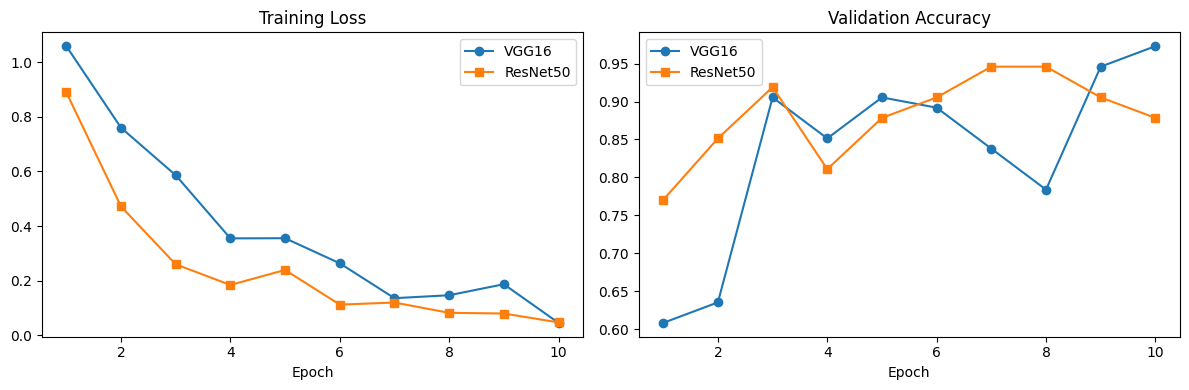

Plot saved!


In [19]:
epochs_range = range(1, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, vgg_losses, label="VGG16", marker='o')
ax1.plot(epochs_range, resnet_losses, label="ResNet50", marker='s')
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs_range, vgg_accs, label="VGG16", marker='o')
ax2.plot(epochs_range, resnet_accs, label="ResNet50", marker='s')
ax2.set_title("Validation Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()
print("Plot saved!")